In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chemevo import evolution_V1 as evo
from chemevo.iterative_1D_method import get_sampled_gals
import chemevo.plotstyle

chemevo.plotstyle.use()

ModuleNotFoundError: No module named 'chemevo'

In [6]:
best_fits_low_res = pd.read_csv("convergence_test_output/convergence_summary.csv")
best_fits_low_res = best_fits_low_res.drop_duplicates(subset="reduced_chi2", keep='first')
best_fits_low_res

,swept_param,alpha_cc_init,alpha_Ia_init,g_cc_init,g_ratio_init,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio,reduced_chi2
0,alpha_cc,0.1,0.3,0.4,1.8,0.3,0.5,0.4,1.7,0.011581
1,alpha_cc,0.2,0.3,0.4,1.8,0.4,0.3,0.4,1.7,0.008627
6,alpha_cc,0.7,0.3,0.4,1.8,0.5,0.2,0.4,1.7,0.008112
7,alpha_cc,0.8,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
16,alpha_Ia,0.4,0.8,0.4,1.8,0.2,0.8,0.4,1.8,0.018915
18,g_cc,0.4,0.3,0.1,1.8,0.4,0.1,0.3,2.4,0.006651
22,g_cc,0.4,0.3,0.5,1.8,0.5,0.3,0.5,1.2,0.013491
26,g_cc,0.4,0.3,0.9,1.8,0.4,0.5,0.5,1.2,0.016955
28,g_ratio,0.4,0.3,0.4,1.0,0.4,0.1,0.4,1.4,0.012296
30,g_ratio,0.4,0.3,0.4,1.5,0.3,0.3,0.4,1.5,0.013440


In [9]:
t_array = np.linspace(0.0001,14,int(1e2))
def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

m_g_array_rise_fall_1 = rise_fall(t_array, 2, 8)
m_g_array_rise_fall_1 /= np.trapezoid(m_g_array_rise_fall_1, t_array)

m_g_array_rise_fall_2 = rise_fall(t_array, 4, 30)
m_g_array_rise_fall_2 /= np.trapezoid(m_g_array_rise_fall_2, t_array)

m_g_array_rise_fall_3 = rise_fall(t_array, 6, 12)
m_g_array_rise_fall_3 /= np.trapezoid(m_g_array_rise_fall_3, t_array)

etas =np.logspace(-2, 0.3, 10)
tau_stars =np.linspace(1, 6, 10)

In [16]:
gals_list = []
yields_Ia = []
yields_cc = []
eta = 0
tau_star = 2
sfr = m_g_array_rise_fall_1

for i in range(len(best_fits_low_res)):
    best_alpha_cc = best_fits_low_res['best_alpha_cc'].iloc[i]
    best_alpha_Ia = best_fits_low_res['best_alpha_Ia'].iloc[i]
    best_g_cc = best_fits_low_res['best_g_cc'].iloc[i]
    best_g_ratio = best_fits_low_res['best_g_ratio'].iloc[i]

    gal = evo.Galaxy(t_array=t_array, m_g_array=sfr, tau_star=tau_star,
                 eta=eta, Upsilon=1, yields_ref="W2024,moreFe",
                 g_cc_Mn=best_g_cc, g_ratio_Mn=best_g_ratio,
                alpha_cc_Mn=best_alpha_cc, alpha_Ia_Mn=best_alpha_Ia)
    
    gals_list.append(gal)
    

In [13]:
gal_temp = gals_list[0]
yield_Ia = gal_temp.compute_y_Mn_Ia()
yield_cc = gal_temp.compute_y_Mn_CC()

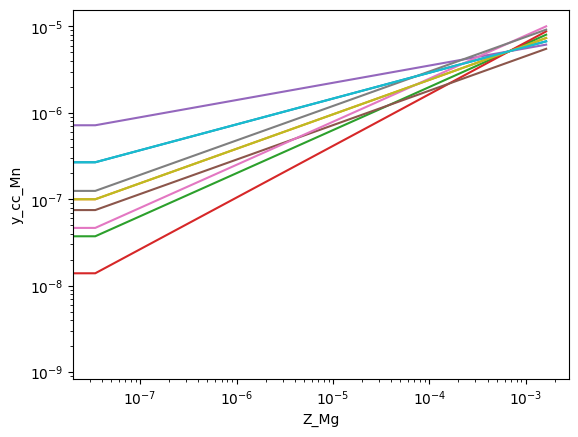

In [20]:
for gal_temp in gals_list:
    yield_Ia = gal_temp.compute_y_Mn_Ia()
    yield_cc = gal_temp.compute_y_Mn_CC()
    Z_Mg = gal_temp.compute_z_Mg()

    plt.plot(Z_Mg, yield_cc)
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel("Z_Mg")
    plt.ylabel("y_cc_Mn")

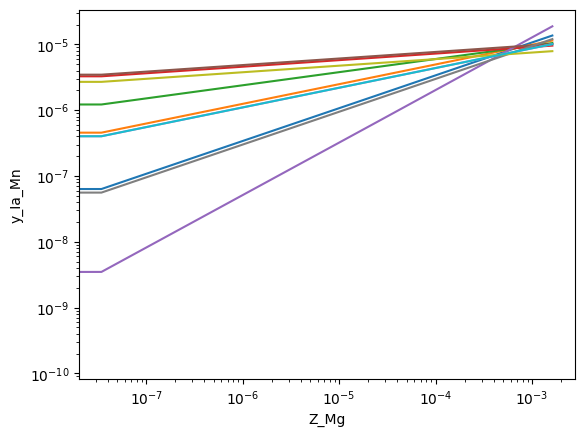

In [22]:
for gal_temp in gals_list:
    yield_Ia = gal_temp.compute_y_Mn_Ia()
    yield_cc = gal_temp.compute_y_Mn_CC()
    Z_Mg = gal_temp.compute_z_Mg()

    plt.plot(Z_Mg, yield_Ia)
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel("Z_Mg")
    plt.ylabel("y_Ia_Mn")

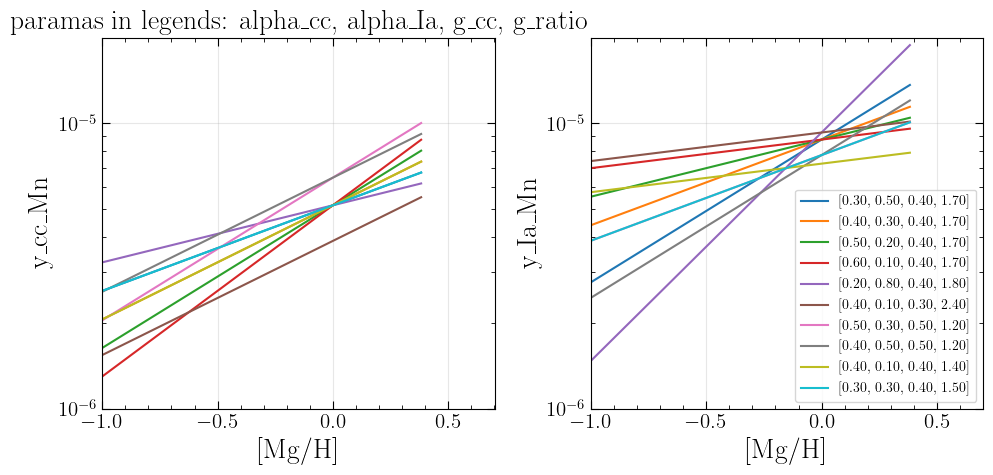

In [49]:
plt.figure(figsize=(10,5))
for gal_temp in gals_list:
    yield_Ia = gal_temp.compute_y_Mn_Ia()
    yield_cc = gal_temp.compute_y_Mn_CC()
    Mg_H = gal_temp.Mg_H

    plt.subplot(1,2,1)
    plt.plot(Mg_H, yield_cc,
             label = f'[{gal_temp.alpha_cc_Mn:.2f}, {gal_temp.alpha_Ia_Mn:.2f}, {gal_temp.g_cc_Mn:.2f}, {gal_temp.g_ratio_Mn:.2f}]')
    plt.yscale('log')
    plt.xlabel("[Mg/H]")
    plt.ylabel("y_cc_Mn")
    plt.xlim(-1,)
    plt.ylim(10**-6, 2 * 10**-5)
    plt.grid('True', alpha = 0.3)
    plt.title("paramas in legends: alpha_cc, alpha_Ia, g_cc, g_ratio")

    plt.subplot(1,2,2)
    plt.plot(Mg_H, yield_Ia,
            label = f'[{gal_temp.alpha_cc_Mn:.2f}, {gal_temp.alpha_Ia_Mn:.2f}, {gal_temp.g_cc_Mn:.2f}, {gal_temp.g_ratio_Mn:.2f}]')
    plt.yscale('log')
    plt.xlabel("[Mg/H]")
    plt.ylabel("y_Ia_Mn")
    plt.xlim(-1,)
    plt.ylim(10**-6, 2 * 10**-5)
    plt.grid('True', alpha = 0.3)
    plt.legend(loc = 'lower right', fontsize=10)

plt.tight_layout()

In [2]:
np.round(np.arange(0.1, 0.9 + 0.001, 0.1), 2)

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])